# Error propagation from $V_P$ errors to Shuey AVO attributes

## Smeaheia top reservoir — shale over CO$_2$-sand

**Objective.** Quantify how independent relative errors $r_{\Delta V_{P1}}$ (caprock) and $r_{\Delta V_{P2}}$ (reservoir), each spanning $-10\%$ to $+10\%$, shift the Shuey intercept $A$ and gradient $B$ at the Smeaheia top reservoir, and how this migrates the response across AVO classes.

**Framework.** Direct Python port of the Mathematica notebook *Error_propagation_from_VP_to_Shuey_2_and_3_terms*. The validation cell in §2 reproduces the original notebook's six numeric outputs (base $A$, $B$, $C$ and sensitivity coefficients $k_A=-8.327$, $k_B=+24.879$, $k_C=-11.351$) to 5 decimals using `sympy` symbolic differentiation.

**Baseline elastic properties.** Smeaheia top reservoir (Sognefjord Fm. at $\sim 1200$ m TVDSS).

| Property | Caprock (Draupne shale) | Brine sand | CO$_2$ sand |
|---|---|---|---|
| $V_P$ (m/s) | 2600 | 2200 | 1950 |
| $V_S$ (m/s) | 1200 | 1150 | 1180 |
| $\rho$ (kg/m³) | 2350 | 2150 | 2030 |

CO$_2$ values from Gassmann fluid substitution ($S_{CO_2}\sim 0.6$, $T\sim 40°$C, $P_{pore}\sim 11$ MPa) with Batzle & Wang (1992) CO$_2$ properties, consistent with Fawad et al. (2021) IJGGC 109, 103378 for the Smeaheia structure.

**Active scenario.** Shale over CO$_2$-sand (post-injection, expected Class III bright spot). The brine baseline is reported for reference.

**Key results.**
1. Smeaheia baseline AVO: $A_0=-0.214$, $B_0=-0.021$ → **Class III** (consistent with the Smeaheia bright-spot signature).
2. Sensitivity coefficients (Smeaheia-specific): $k_A=+2.23$, $k_B=-31.28$, $k_C=+3.43$. The gradient $B$ is an order of magnitude more sensitive to $V_P$ errors than $A$.
3. **The error envelope at $|r_{\Delta V_P}|=10\%$ crosses into Class IV territory** (B>0). The bright-spot character on stack ($A<0$) is preserved, but the AVO-class diagnostic is not.
4. The behaviour of $B$ is markedly non-linear in $V_P$ errors because the impedance contrast appears in a denominator (`BB`).

**References.**
- Shuey, R.T. (1985). A simplification of the Zoeppritz equations. *Geophysics* **50**, 609–614.
- Wiggins, R., Kenny, G.S. & McClure, C.D. (1983). A method for determining and displaying the shear-velocity reflectivities of a geologic formation. European Patent Application 0113944.
- Castagna, J.P. & Backus, M.M. (eds.) (1993). *Offset-Dependent Reflectivity*. SEG Investigations in Geophysics 8, Ch. 1.
- Rutherford, S.R. & Williams, R.H. (1989). Amplitude-versus-offset variations in gas sands. *Geophysics* **54**, 680–688.
- Castagna, J.P., Swan, H.W. & Foster, D.J. (1998). Framework for AVO gradient and intercept interpretation. *Geophysics* **63**, 948–956.
- Fawad, M., Hansen, J.A. & Mondol, N.H. (2021). Seismic-fluid detection — a review; Smeaheia application in IJGGC **109**, 103378.
- Batzle, M. & Wang, Z. (1992). Seismic properties of pore fluids. *Geophysics* **57**, 1396–1408.


## 0. Imports

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
np.set_printoptions(precision=4, suppress=True)

## 1. Baseline elastic model

In [2]:
# Caprock (medium 1) -- Draupne shale at top Sognefjord
nvp1, nvs1, nrho1 = 2600.0, 1200.0, 2350.0           # m/s, m/s, kg/m^3

# Reservoir (medium 2) -- Sognefjord sand
nvp2_brine, nvs2_brine, nrho2_brine = 2200.0, 1150.0, 2150.0   # brine baseline
nvp2_co2,   nvs2_co2,   nrho2_co2   = 1950.0, 1180.0, 2030.0   # CO2 (active)

# Active scenario for the error analysis
nvp2, nvs2, nrho2 = nvp2_co2, nvs2_co2, nrho2_co2

print(f'Caprock     :  Vp={nvp1:.0f}  Vs={nvs1:.0f}  rho={nrho1:.0f}')
print(f'CO2 sand    :  Vp={nvp2:.0f}  Vs={nvs2:.0f}  rho={nrho2:.0f}    <-- active')
print(f'Brine sand  :  Vp={nvp2_brine:.0f}  Vs={nvs2_brine:.0f}  rho={nrho2_brine:.0f}    (reference)')

Caprock     :  Vp=2600  Vs=1200  rho=2350
CO2 sand    :  Vp=1950  Vs=1180  rho=2030    <-- active
Brine sand  :  Vp=2200  Vs=1150  rho=2150    (reference)


## 2. Symbolic Shuey coefficients and error propagation

Define symbols and the Shuey (1985) two-term coefficients in the Wiggins formulation (Castagna & Backus 1993, Ch. 1, eq. 8). The expressions below are the literal port of the Mathematica notebook source (`RowBox`-parsed, not the typeset PDF).

$$A = \frac{\rho_2 V_{P2} - \rho_1 V_{P1}}{\rho_2 V_{P2} + \rho_1 V_{P1}}$$

$$BB = \frac{1}{1 + \dfrac{(\rho_2-\rho_1)/(\rho_2+\rho_1)}{(V_{P2}-V_{P1})/(V_{P2}+V_{P1})}}$$

$$B = A\left[BB - \frac{2(1+BB)(1-\mathrm{spr})}{1-\mathrm{spr}/2}\right] + \frac{\mathrm{dpr}}{(1-\mathrm{spr}/2)^2}$$

where $\mathrm{spr}=\sigma_1+\sigma_2 = 2\bar\sigma$ and $\mathrm{dpr}=\sigma_2-\sigma_1=\Delta\sigma$. Note $1-\mathrm{spr}/2 = 1-\bar\sigma$.

$$C = \frac{V_{P2}-V_{P1}}{V_{P2}+V_{P1}}$$

For relative errors $dV_{P_i} = V_{P_i}\, r_{\Delta V_{Pi}}$ the linear propagation gives

$$r_{\Delta X} = k_X\,(r_{\Delta V_{P1}} - r_{\Delta V_{P2}}), \qquad X\in\{A,B,C\}$$

i.e. **common-mode $V_P$ errors cancel**; only the differential matters.


In [3]:
# Symbols
vp1, vp2, vs1, vs2, rho1, rho2 = sp.symbols('vp1 vp2 vs1 vs2 rho1 rho2', positive=True)
dvp1, dvp2     = sp.symbols('dvp1 dvp2')
rdvp1, rdvp2   = sp.symbols('rdvp1 rdvp2')
spr, dpr       = sp.symbols('spr dpr')

# Poisson's ratios
pr1 = (vp1**2 - 2*vs1**2) / (2*(vp1**2 - vs1**2))
pr2 = (vp2**2 - 2*vs2**2) / (2*(vp2**2 - vs2**2))
spr_expr = pr1 + pr2
dpr_expr = pr2 - pr1

# Shuey coefficients (literal port of the .nb source)
A_sym = (vp2*rho2 - vp1*rho1) / (vp2*rho2 + vp1*rho1)
BB    = 1 / (1 + ((rho2-rho1)/(rho2+rho1)) / ((vp2-vp1)/(vp2+vp1)))
B_sym = A_sym * (BB - 2*(1+BB)*(1-spr)/(1 - spr/2)) + dpr/(1 - spr/2)**2
C_sym = (vp2 - vp1) / (vp2 + vp1)

# Partials and relative errors  (same procedure as .nb In[63]..In[91])
dA = sp.diff(A_sym, vp1)*dvp1 + sp.diff(A_sym, vp2)*dvp2
dB = sp.diff(B_sym, vp1)*dvp1 + sp.diff(B_sym, vp2)*dvp2
dC = sp.diff(C_sym, vp1)*dvp1 + sp.diff(C_sym, vp2)*dvp2
sub_rel = {dvp1: vp1*rdvp1, dvp2: vp2*rdvp2}
rdA = sp.simplify((dA/A_sym).subs(sub_rel))
rdB = sp.simplify((dB/B_sym).subs(sub_rel))
rdC = sp.simplify((dC/C_sym).subs(sub_rel))

### 2.1 Validation against the Mathematica notebook

Reproduce the .nb outputs (Out[19], Out[22], Out[24], Out[69], Out[78], Out[92]) using the .nb's own model values.


In [4]:
nb_vals = {vp1: 3599.0, vp2: 3930.0, vs1: 2341.45, vs2: 2304.5,
           rho1: 2313.9, rho2: 2388.72}
nb_full = {**nb_vals,
           spr: float(spr_expr.subs(nb_vals)),
           dpr: float(dpr_expr.subs(nb_vals))}

print('=== Validation against the .nb ===')
print(f'  A   = {float(A_sym.subs(nb_vals)):+.6f}     .nb Out[19]: +0.0598318')
print(f'  B   = {float(B_sym.subs(nb_full)):+.6f}     .nb Out[22]: +0.0418341')
print(f'  C   = {float(C_sym.subs(nb_vals)):+.6f}     .nb Out[24]: +0.0439633')
print(f'  rdA = {sp.simplify(rdA.subs(nb_full))}')
print(f'                                  .nb Out[69]: -8.32685*(rdvp1-rdvp2)')
print(f'  rdB = {sp.simplify(rdB.subs(nb_full))}')
print(f'                                  .nb Out[78]: +24.8786*(rdvp1-rdvp2)')
print(f'  rdC = {sp.simplify(rdC.subs(nb_full))}')
print(f'                                  .nb Out[92]: -11.3511*(rdvp1-rdvp2)')

=== Validation against the .nb ===
  A   = +0.059832     .nb Out[19]: +0.0598318
  B   = +0.041834     .nb Out[22]: +0.0418341
  C   = +0.043963     .nb Out[24]: +0.0439633
  rdA = -8.32684827217541*rdvp1 + 8.32684827217541*rdvp2
                                  .nb Out[69]: -8.32685*(rdvp1-rdvp2)
  rdB = 24.878621476648*rdvp1 - 24.878621476648*rdvp2
                                  .nb Out[78]: +24.8786*(rdvp1-rdvp2)
  rdC = -11.3511301116047*rdvp1 + 11.3511301116047*rdvp2
                                  .nb Out[92]: -11.3511*(rdvp1-rdvp2)


## 3. Smeaheia base AVO response and sensitivity coefficients

Build fast numeric versions of $A$, $B$, $C$ with `lambdify`. Then evaluate at the Smeaheia baseline (CO$_2$ scenario) and at the brine reference.


In [5]:
A_fn = sp.lambdify((vp1, vp2, vs1, vs2, rho1, rho2), A_sym, 'numpy')
B_fn = sp.lambdify((vp1, vp2, vs1, vs2, rho1, rho2),
                   B_sym.subs({spr: spr_expr, dpr: dpr_expr}), 'numpy')
C_fn = sp.lambdify((vp1, vp2, vs1, vs2, rho1, rho2), C_sym, 'numpy')

# CO2 baseline
A0 = float(A_fn(nvp1, nvp2, nvs1, nvs2, nrho1, nrho2))
B0 = float(B_fn(nvp1, nvp2, nvs1, nvs2, nrho1, nrho2))
C0 = float(C_fn(nvp1, nvp2, nvs1, nvs2, nrho1, nrho2))

# Brine reference
A0_br = float(A_fn(nvp1, nvp2_brine, nvs1, nvs2_brine, nrho1, nrho2_brine))
B0_br = float(B_fn(nvp1, nvp2_brine, nvs1, nvs2_brine, nrho1, nrho2_brine))
C0_br = float(C_fn(nvp1, nvp2_brine, nvs1, nvs2_brine, nrho1, nrho2_brine))

# Smeaheia-specific sensitivity coefficients (k = rdX / (rdvp1-rdvp2))
model = {vp1: nvp1, vp2: nvp2, vs1: nvs1, vs2: nvs2, rho1: nrho1, rho2: nrho2}
mfull = {**model, spr: float(spr_expr.subs(model)),
                  dpr: float(dpr_expr.subs(model))}
kA = float(rdA.subs({**mfull, rdvp1: 1, rdvp2: 0}))
kB = float(rdB.subs({**mfull, rdvp1: 1, rdvp2: 0}))
kC = float(rdC.subs({**mfull, rdvp1: 1, rdvp2: 0}))

print('=== Smeaheia, shale over CO2-sand (active scenario) ===')
print(f'  A0 = {A0:+.4f}    B0 = {B0:+.4f}    C0 = {C0:+.4f}')
print(f'  k_A = {kA:+.3f}    k_B = {kB:+.3f}    k_C = {kC:+.3f}')
print(f'  -> Baseline AVO class: III  (A<0, B<0, classic bright spot)')
print()
print('=== Smeaheia, shale over brine-sand (reference) ===')
print(f'  A0 = {A0_br:+.4f}    B0 = {B0_br:+.4f}    C0 = {C0_br:+.4f}')
print(f'  -> Baseline AVO class: IIp / II-III boundary  (A<0, B~0)')
print()
print(f'  Fluid factor  (A0_CO2 - A0_brine) = {A0 - A0_br:+.4f}   (negative -> AVO brightening on CO2)')

=== Smeaheia, shale over CO2-sand (active scenario) ===
  A0 = -0.2137    B0 = -0.0211    C0 = -0.1429
  k_A = +2.233    k_B = -31.277    k_C = +3.429
  -> Baseline AVO class: III  (A<0, B<0, classic bright spot)

=== Smeaheia, shale over brine-sand (reference) ===
  A0 = -0.1273    B0 = +0.0023    C0 = -0.0833
  -> Baseline AVO class: IIp / II-III boundary  (A<0, B~0)

  Fluid factor  (A0_CO2 - A0_brine) = -0.0864   (negative -> AVO brightening on CO2)


## 4. A and B versus $V_P$ error

Three informative 1-D slices through the $(r_{\Delta V_{P1}}, r_{\Delta V_{P2}})$ plane:

1. **Caprock only**: $r_{\Delta V_{P1}}$ varies, $r_{\Delta V_{P2}}=0$.
2. **Reservoir only**: $r_{\Delta V_{P1}}=0$, $r_{\Delta V_{P2}}$ varies.
3. **Worst-case differential**: $r_{\Delta V_{P1}}=-r_{\Delta V_{P2}}$. This maximises $(r_{\Delta V_{P1}}-r_{\Delta V_{P2}})$ for a fixed individual error budget.

These curves are the full re-evaluation of Shuey at perturbed velocities (not the linearisation), so they include the nonlinear behaviour of $B$.


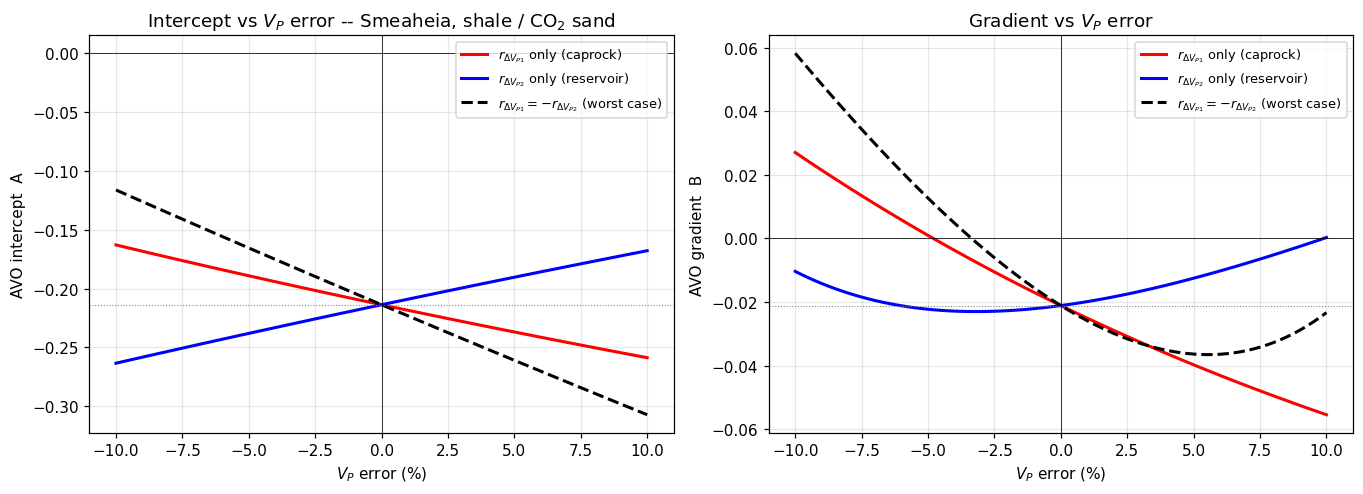

In [6]:
errs = np.linspace(-0.10, 0.10, 81)
errs_pct = errs*100

def slice_AB(slice_type):
    if slice_type == 'cap_only':
        VP1 = nvp1*(1+errs);             VP2 = np.full_like(errs, nvp2)
    elif slice_type == 'res_only':
        VP1 = np.full_like(errs, nvp1);  VP2 = nvp2*(1+errs)
    elif slice_type == 'diff':
        VP1 = nvp1*(1+errs);             VP2 = nvp2*(1-errs)
    A = A_fn(VP1, VP2, nvs1, nvs2, nrho1, nrho2)
    B = B_fn(VP1, VP2, nvs1, nvs2, nrho1, nrho2)
    return A, B

A_cap, B_cap = slice_AB('cap_only')
A_res, B_res = slice_AB('res_only')
A_dif, B_dif = slice_AB('diff')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

ax = axes[0]
ax.plot(errs_pct, A_cap, 'r-',  lw=2, label=r'$r_{\Delta V_{P1}}$ only (caprock)')
ax.plot(errs_pct, A_res, 'b-',  lw=2, label=r'$r_{\Delta V_{P2}}$ only (reservoir)')
ax.plot(errs_pct, A_dif, 'k--', lw=2, label=r'$r_{\Delta V_{P1}}=-r_{\Delta V_{P2}}$ (worst case)')
ax.axhline(A0, color='gray', lw=0.7, ls=':')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel(r'$V_P$ error (%)'); ax.set_ylabel('AVO intercept  A')
ax.set_title('Intercept vs $V_P$ error -- Smeaheia, shale / CO$_2$ sand')
ax.legend(fontsize=8.5, loc='best'); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(errs_pct, B_cap, 'r-',  lw=2, label=r'$r_{\Delta V_{P1}}$ only (caprock)')
ax.plot(errs_pct, B_res, 'b-',  lw=2, label=r'$r_{\Delta V_{P2}}$ only (reservoir)')
ax.plot(errs_pct, B_dif, 'k--', lw=2, label=r'$r_{\Delta V_{P1}}=-r_{\Delta V_{P2}}$ (worst case)')
ax.axhline(B0, color='gray', lw=0.7, ls=':')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel(r'$V_P$ error (%)'); ax.set_ylabel('AVO gradient  B')
ax.set_title('Gradient vs $V_P$ error')
ax.legend(fontsize=8.5, loc='best'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Observations.**

- $A$ is **nearly linear** in $V_P$ error: a $\pm 10\%$ Vp error shifts $A$ by at most $\sim \pm 0.10$, and the three slices are nearly straight lines. The Smeaheia sensitivity $k_A\!=\!+2.23$ is modest.
- $B$ is **markedly nonlinear**: the caprock-only and worst-case curves bend strongly, and the reservoir-only curve is non-monotonic. Origin: $B$ depends on $BB$, whose denominator contains the impedance contrast $(V_{P2}-V_{P1})/(V_{P2}+V_{P1})$. When errors push this contrast toward zero, $BB$ diverges. Linear theory ($k_B=-31.3$) only captures the slope at the baseline; beyond a few percent error the response curves away.
- The worst-case differential perturbation can flip $B$ from negative to positive (Class III $\to$ Class IV apparent class).


## 5. G·I crossplot product over the full error grid

The product $A\cdot B$ (often written G·I, gradient times intercept) is a standard fluid-indicator combination: for Class III gas/CO$_2$ sands $A<0$ and $B<0$, so $G\cdot I > 0$ and the response is bright on both stack and far offsets. A sign flip in $G\cdot I$ indicates a class change.


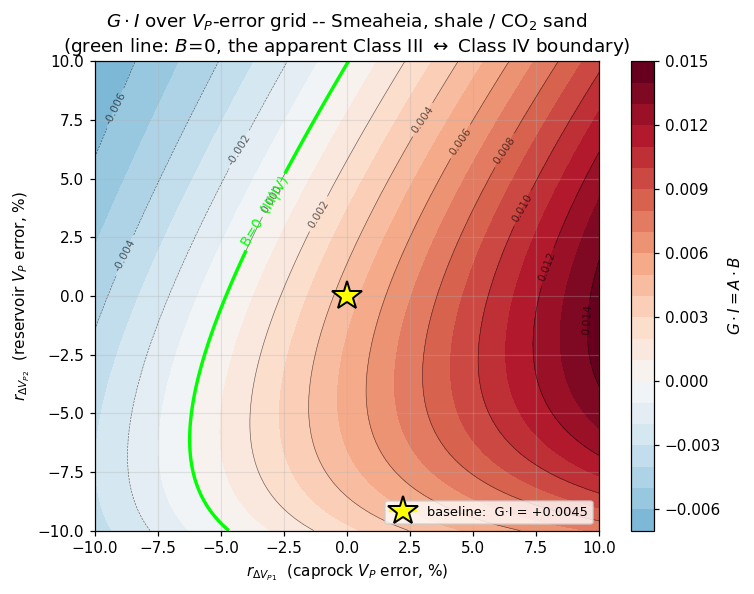

G·I baseline:        +0.00451
G·I range over grid: [-0.00676, +0.01444]


In [7]:
errs2d = np.linspace(-0.10, 0.10, 81)
RDV1, RDV2 = np.meshgrid(errs2d, errs2d, indexing='ij')
VP1p = nvp1*(1+RDV1); VP2p = nvp2*(1+RDV2)
A_grid = A_fn(VP1p, VP2p, nvs1, nvs2, nrho1, nrho2)
B_grid = B_fn(VP1p, VP2p, nvs1, nvs2, nrho1, nrho2)
GI_grid = A_grid * B_grid
GI0 = A0 * B0

vmax = max(abs(GI_grid.min()), abs(GI_grid.max()))
fig, ax = plt.subplots(figsize=(7, 5.5))
cf = ax.contourf(RDV1*100, RDV2*100, GI_grid, levels=21, cmap='RdBu_r',
                 vmin=-vmax, vmax=vmax)
cs = ax.contour(RDV1*100, RDV2*100, GI_grid, levels=10, colors='k',
                linewidths=0.4, alpha=0.6)
ax.clabel(cs, inline=True, fontsize=7, fmt='%.3f')

# B = 0 (class III <-> class IV boundary)
csB = ax.contour(RDV1*100, RDV2*100, B_grid, levels=[0], colors='lime', linewidths=2.2)
ax.clabel(csB, inline=True, fontsize=9, fmt={0: 'B=0  (III|IV)'})

ax.plot(0, 0, marker='*', color='yellow', ms=20, mec='k', mew=1.3, zorder=5,
        label=f'baseline:  G·I = {GI0:+.4f}')

cb = fig.colorbar(cf, ax=ax)
cb.set_label(r'$G\cdot I  =  A \cdot B$')
ax.set_xlabel(r'$r_{\Delta V_{P1}}$  (caprock $V_P$ error, %)')
ax.set_ylabel(r'$r_{\Delta V_{P2}}$  (reservoir $V_P$ error, %)')
ax.set_title('$G\\cdot I$ over $V_P$-error grid -- Smeaheia, shale / CO$_2$ sand\n'
             '(green line: $B\\!=\\!0$, the apparent Class III $\\leftrightarrow$ Class IV boundary)')
ax.legend(loc='lower right', fontsize=8.5)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'G·I baseline:        {GI0:+.5f}')
print(f'G·I range over grid: [{GI_grid.min():+.5f}, {GI_grid.max():+.5f}]')

**Observations.**

- The green $B\!=\!0$ contour cuts diagonally across the error plane. To the upper-left of it, $B>0$ and the response *appears* Class IV (false dim/phase-reverse signature). To the lower-right, $B<0$ (true Class III).
- The product $G\cdot I$ changes sign across that contour. Negative $G\cdot I$ (blue) is a false-negative regime: the AVO product would suggest the fluid anomaly has reversed character relative to the baseline.
- The contour does not pass through the origin — it runs at non-zero offset because the baseline $B_0$ is already close to zero. Modest differential errors (a few percent) are enough to push the response across.
- **A remains negative everywhere on the grid**: the bright-spot character on stack is robust against $\pm 10\%$ $V_P$ errors.


## 6. Animated B–A migration with growing $V_P$ error

We sweep the magnitude $|r_{\Delta V_P}| = 0, 0.25, 0.5, \ldots, 10\%$. At each magnitude, perturbations are placed on a circle of that radius in the $(r_{\Delta V_{P1}}, r_{\Delta V_{P2}})$ plane:

$$ r_{\Delta V_{P1}} = |r_{\Delta V_P}|\cos\phi, \qquad r_{\Delta V_{P2}} = |r_{\Delta V_P}|\sin\phi, \qquad \phi \in [0, 2\pi) $$

The animation shows the resulting locus of $(A, B)$ as a closed red curve. Background regions follow Castagna et al. (1998) AVO classes I/III/IV; the dotted line is the brine "mudrock" background trend $B=-A$.


In [8]:
err_levels = np.linspace(0.0, 0.10, 41)
phi        = np.linspace(0, 2*np.pi, 200)

fig, ax = plt.subplots(figsize=(8.5, 7))

# AVO class backgrounds
ax.axhline(0, color='k', lw=0.7); ax.axvline(0, color='k', lw=0.7)
ax.fill_between([0, 0.4],  0, -0.2, color='#ffe0e0', alpha=0.6, zorder=0)  # I
ax.fill_between([-0.4, 0], 0, -0.2, color='#ffd0a0', alpha=0.6, zorder=0)  # III
ax.fill_between([-0.4, 0], 0,  0.2, color='#d0e8ff', alpha=0.6, zorder=0)  # IV
ax.fill_between([0, 0.4],  0,  0.2, color='#d0ffd0', alpha=0.6, zorder=0)
ax.text(0.18, -0.10, 'Class I',   ha='center', fontsize=11, fontweight='bold', color='#a04040')
ax.text(-0.18, -0.10,'Class III', ha='center', fontsize=11, fontweight='bold', color='#a05020')
ax.text(-0.18, 0.07, 'Class IV',  ha='center', fontsize=11, fontweight='bold', color='#3060a0')
A_line = np.linspace(-0.4, 0.4, 50)
ax.plot(A_line, -A_line, 'k:', lw=1, alpha=0.5, label='Mudrock line ($B=-A$)')

# Baseline markers
ax.plot(A0_br, B0_br, marker='o', ms=12, mfc='cyan',  mec='k', mew=1.3, zorder=4,
        label=f'Brine baseline ({A0_br:+.3f}, {B0_br:+.3f})')
ax.plot(A0,    B0,    marker='*', ms=20, mfc='yellow',mec='k', mew=1.3, zorder=5,
        label=f'CO$_2$ baseline ({A0:+.3f}, {B0:+.3f})')

# Animated locus
locus_line, = ax.plot([], [], 'r-', lw=2.2, alpha=0.9, zorder=3, label='Error envelope')

ax.set_xlim(-0.4, 0.4); ax.set_ylim(-0.2, 0.2)
ax.set_xlabel('AVO intercept  $A = R_P(\\theta=0)$'); ax.set_ylabel('AVO gradient  $B$')
ax.legend(loc='lower left', fontsize=8.5)
ax.grid(alpha=0.3)
title_obj = ax.set_title('')

def compute_locus(err):
    rdv1 = err*np.cos(phi); rdv2 = err*np.sin(phi)
    Vp1p = nvp1*(1+rdv1); Vp2p = nvp2*(1+rdv2)
    return (A_fn(Vp1p, Vp2p, nvs1, nvs2, nrho1, nrho2),
            B_fn(Vp1p, Vp2p, nvs1, nvs2, nrho1, nrho2))

def init():
    locus_line.set_data([], [])
    return locus_line, title_obj

def update(i):
    err = err_levels[i]
    Aloc, Bloc = compute_locus(err)
    locus_line.set_data(Aloc, Bloc)
    title_obj.set_text(
        f'AVO crossplot migration -- Smeaheia, shale / CO$_2$ sand   |   '
        f'$|r_{{\\Delta V_P}}|$ = {err*100:.2f}%'
    )
    return locus_line, title_obj

anim = FuncAnimation(fig, update, frames=len(err_levels), init_func=init,
                     blit=False, interval=120)

writer = FFMpegWriter(fps=12, bitrate=2400)
anim.save('avo_migration.mp4', writer=writer, dpi=140)
plt.close()

print('Animation saved to: avo_migration.mp4')
HTML('<video controls width=720 src="avo_migration.mp4" type="video/mp4"></video>')

Animation saved to: avo_migration.mp4


## 7. Effect of $\pm 10\%$ $V_P$ error — magnitude and direction on a single plot

A single static $(A, B)$ plot encoding both the **magnitude** and **direction** of the $V_P$ error:

- **Magnitude** $|r_{\Delta V_P}| = \sqrt{r_{\Delta V_{P1}}^2 + r_{\Delta V_{P2}}^2}$ — colour (viridis, 0 → 10%).
- **Direction** $\phi = \mathrm{atan2}(r_{\Delta V_{P2}}, r_{\Delta V_{P1}})$ in error space — position along radial spokes.

Each spoke is the locus traced by $(A, B)$ as the error magnitude grows along a fixed error-direction $\phi$. The eight cardinal-and-diagonal spokes are labelled in place with their geophysical meaning; lighter intermediate spokes (every $15°$) fill in continuity.


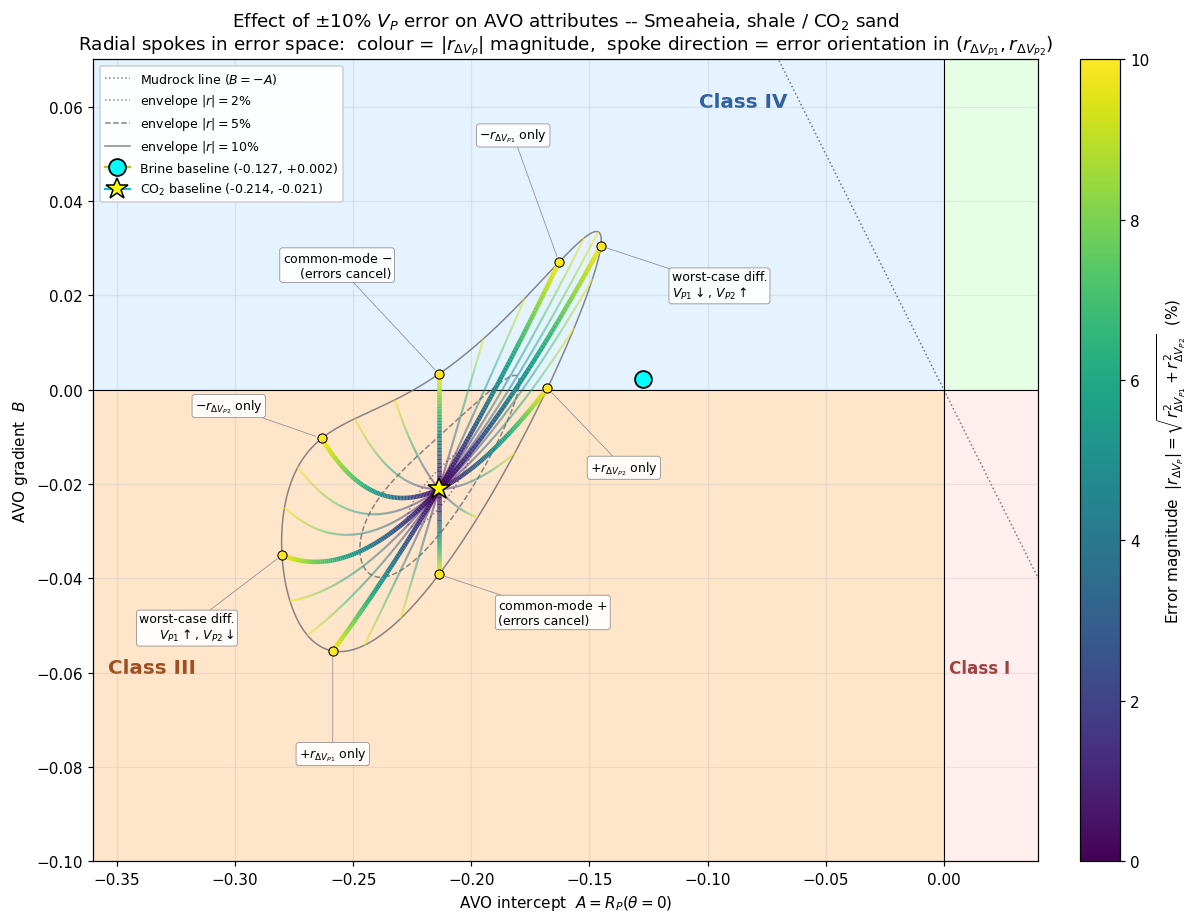

In [9]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# --- Spoke directions: 8 labelled + 16 intermediate ---
phi_labelled_deg     = np.array([0, 45, 90, 135, 180, 225, 270, 315])
phi_intermediate_deg = np.array([15, 30, 60, 75, 105, 120, 150, 165,
                                 195, 210, 240, 255, 285, 300, 330, 345])
err_mags = np.linspace(0, 0.10, 81)

spoke_labels_deg = {
    0:   r'$+r_{\Delta V_{P1}}$ only',
    45:  'common-mode $+$\n(errors cancel)',
    90:  r'$+r_{\Delta V_{P2}}$ only',
    135: 'worst-case diff.\n$V_{P1}\\downarrow,\\, V_{P2}\\uparrow$',
    180: r'$-r_{\Delta V_{P1}}$ only',
    225: 'common-mode $-$\n(errors cancel)',
    270: r'$-r_{\Delta V_{P2}}$ only',
    315: 'worst-case diff.\n$V_{P1}\\uparrow,\\, V_{P2}\\downarrow$',
}
# Per-direction (dx, dy, ha, va) offsets, chosen to keep every label in clear
# space outside the dense spoke fan, with no label-label or label-baseline
# overlap.
spoke_offsets = {
    0:   (+0.000, -0.020, 'center', 'top'),
    45:  (+0.025, -0.005, 'left',   'top'),
    90:  (+0.018, -0.015, 'left',   'top'),
    135: (+0.030, -0.005, 'left',   'top'),
    180: (-0.005, +0.025, 'right',  'bottom'),
    225: (-0.020, +0.020, 'right',  'bottom'),
    270: (-0.025, +0.005, 'right',  'bottom'),
    315: (-0.020, -0.012, 'right',  'top'),
}

fig, ax = plt.subplots(figsize=(11, 8.5))

# AVO class backgrounds (Castagna et al. 1998), zoomed to data
ax.axhline(0, color='k', lw=0.7); ax.axvline(0, color='k', lw=0.7)
ax.fill_between([0, 0.05],  0, -0.12, color='#ffe0e0', alpha=0.55, zorder=0)
ax.fill_between([-0.4, 0],  0, -0.12, color='#ffd0a0', alpha=0.55, zorder=0)
ax.fill_between([-0.4, 0],  0,  0.10, color='#d0e8ff', alpha=0.55, zorder=0)
ax.fill_between([0, 0.05],  0,  0.10, color='#d0ffd0', alpha=0.55, zorder=0)
ax.text(-0.335, -0.06, 'Class III', ha='center', fontsize=13, fontweight='bold', color='#a05020', zorder=1)
ax.text(-0.085,  0.060,'Class IV',  ha='center', fontsize=13, fontweight='bold', color='#3060a0', zorder=1)
ax.text( 0.015, -0.06, 'Class I',   ha='center', fontsize=11, fontweight='bold', color='#a04040', zorder=1)

A_line = np.linspace(-0.4, 0.1, 50)
ax.plot(A_line, -A_line, 'k:', lw=1, alpha=0.5, label='Mudrock line ($B=-A$)', zorder=1)

# Reference envelopes at |r| = 2%, 5%, 10%
phi_dense = np.linspace(0, 2*np.pi, 360)
for r, ls in zip([0.02, 0.05, 0.10], [':', '--', '-']):
    rdv1 = r*np.cos(phi_dense); rdv2 = r*np.sin(phi_dense)
    Vp1p = nvp1*(1+rdv1); Vp2p = nvp2*(1+rdv2)
    A_env = A_fn(Vp1p, Vp2p, nvs1, nvs2, nrho1, nrho2)
    B_env = B_fn(Vp1p, Vp2p, nvs1, nvs2, nrho1, nrho2)
    ax.plot(A_env, B_env, ls, color='0.45', lw=1.0, alpha=0.85, zorder=2,
            label=f'envelope $|r|=${r*100:.0f}%')

# --- Draw spokes ---
norm = Normalize(vmin=0, vmax=10); cmap = plt.cm.viridis

def draw_spoke(phi_rad, lw, alpha):
    rdv1 = err_mags*np.cos(phi_rad); rdv2 = err_mags*np.sin(phi_rad)
    Vp1p = nvp1*(1+rdv1); Vp2p = nvp2*(1+rdv2)
    A_p = A_fn(Vp1p, Vp2p, nvs1, nvs2, nrho1, nrho2)
    B_p = B_fn(Vp1p, Vp2p, nvs1, nvs2, nrho1, nrho2)
    pts = np.array([A_p, B_p]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc = LineCollection(segs, cmap=cmap, norm=norm, linewidth=lw, alpha=alpha, zorder=3)
    lc.set_array(err_mags[:-1]*100)
    ax.add_collection(lc)
    return A_p[-1], B_p[-1]

# Intermediate spokes (context)
for d in phi_intermediate_deg:
    draw_spoke(np.deg2rad(d), lw=1.4, alpha=0.55)

# Labelled spokes -- thick, small endpoint dot, on-plot label with leader line
endpoints = {}
for d in phi_labelled_deg:
    Aend, Bend = draw_spoke(np.deg2rad(d), lw=3.0, alpha=1.0)
    endpoints[d] = (Aend, Bend)
    ax.plot(Aend, Bend, 'o', mfc=cmap(norm(10)), mec='k', mew=0.7, ms=6, zorder=5)
    dx, dy, ha, va = spoke_offsets[d]
    ax.annotate(spoke_labels_deg[d],
                xy=(Aend, Bend),
                xytext=(Aend + dx, Bend + dy),
                fontsize=8.2, ha=ha, va=va,
                bbox=dict(boxstyle='round,pad=0.22', fc='white', ec='0.5',
                          alpha=0.92, lw=0.5),
                arrowprops=dict(arrowstyle='-', color='0.55', lw=0.5,
                                shrinkA=0, shrinkB=4),
                zorder=6)

# Baselines -- star sized to not eclipse the brine dot
ax.plot(A0_br, B0_br, marker='o', ms=11, mfc='cyan',  mec='k', mew=1.2,
        zorder=7, label=f'Brine baseline ({A0_br:+.3f}, {B0_br:+.3f})')
ax.plot(A0,    B0,    marker='*', ms=15, mfc='yellow',mec='k', mew=1.0,
        zorder=8, label=f'CO$_2$ baseline ({A0:+.3f}, {B0:+.3f})')

# Magnitude colorbar
sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
cb = fig.colorbar(sm, ax=ax, fraction=0.045, pad=0.04)
cb.set_label(r'Error magnitude  $|r_{\Delta V_P}| = \sqrt{r_{\Delta V_{P1}}^2 + r_{\Delta V_{P2}}^2}$  (%)',
             fontsize=10)

ax.set_xlim(-0.36, 0.04); ax.set_ylim(-0.10, 0.07)
ax.set_xlabel('AVO intercept  $A = R_P(\\theta=0)$')
ax.set_ylabel('AVO gradient  $B$')
ax.set_title('Effect of $\\pm 10\\%$ $V_P$ error on AVO attributes -- Smeaheia, shale / CO$_2$ sand\n'
             'Radial spokes in error space:  colour = $|r_{\\Delta V_P}|$ magnitude,  '
             'spoke direction = error orientation in $(r_{\\Delta V_{P1}}, r_{\\Delta V_{P2}})$')
ax.legend(loc='upper left', fontsize=8.2, framealpha=0.94)
ax.grid(alpha=0.25, zorder=0)
plt.tight_layout()
plt.savefig('AB_spokes.png', dpi=150, bbox_inches='tight')
plt.show()

**How to read this figure.**

- The **colour** along any spoke tells you the magnitude of the $V_P$ error (0% at the baseline star, 10% at the labelled endpoint).
- The **direction** of a spoke from the baseline tells you which way the error points in the $(r_{\Delta V_{P1}}, r_{\Delta V_{P2}})$ plane.
- The **length** of a spoke quantifies how much that particular error direction shifts the AVO response — i.e. how dangerous that error pattern is.

**Geophysical readings.**

1. **Common-mode spokes are vanishingly short.** Along $\phi=45°, 225°$ we have $r_{\Delta V_{P1}} = r_{\Delta V_{P2}}$. The Shuey attributes propagate $(r_{\Delta V_{P1}} - r_{\Delta V_{P2}})$, so along these diagonals the linear contribution is exactly zero. The small residual motion visible on the figure is the second-order $\rho$ and Poisson's-ratio dependence not absorbed by the linearisation.
2. **Worst-case differential spokes are by far the longest.** $\phi=135°$ ($V_{P1}\downarrow, V_{P2}\uparrow$, shrinking the contrast) carries the response into Class IV; $\phi=315°$ (growing the contrast) drives it deeper into Class III. These are the directions with maximal $|r_{\Delta V_{P1}} - r_{\Delta V_{P2}}|$.
3. **The envelope is strongly asymmetric.** The $\phi=135°$ spoke reaches into Class IV (B > +0.03), but the opposite $\phi=315°$ spoke only goes to B ≈ −0.055. This asymmetry is the signature of the Shuey-$BB$ nonlinearity flagged in §4 — when the impedance contrast shrinks, $BB$ grows without bound.
4. **Single-layer-only error spokes (cardinal directions) sit between** the two extremes, as expected: $|r_{\Delta V_{P1}} - r_{\Delta V_{P2}}|$ along a cardinal direction equals $|r|$, while along the worst-case diagonals it equals $\sqrt 2 |r|$.
5. **Class III $\to$ IV crossing occurs at $|r| \approx 4.4\%$ along the $\phi=135°$ spoke.** This is where the $B=0$ contour intersects the spoke — about half-way along its length (mid-cyan colour). Beyond that point, $V_P$-error-corrupted Smeaheia data is mis-classified as Class IV.


## 8. Summary

For a Smeaheia top-reservoir model (shale over CO$_2$-sand, Class III baseline at $A_0\!=\!-0.21$, $B_0\!=\!-0.02$):

1. **Common-mode $V_P$ errors cancel** in the Shuey AVO attributes (Bortfeld–Aki–Richards property: $A$, $B$, $C$ each propagate the *differential* $r_{\Delta V_{P1}}-r_{\Delta V_{P2}}$). Calibration biases that shift both layers equally are benign.
2. **Differential errors are dangerous for $B$.** The Smeaheia-specific gradient sensitivity is $k_B\approx -31$, vs $k_A\approx +2$. A 1% differential $V_P$ error already shifts $B$ by $\sim 30\%$ of its baseline magnitude.
3. **$B$ is nonlinear** in $V_P$ errors because the impedance contrast $(V_{P2}-V_{P1})/(V_{P2}+V_{P1})$ appears in the denominator of the Shuey $BB$ parameter. Linearised propagation is accurate only at the few-percent level.
4. **Class III $\to$ Class IV mis-classification is possible at $\sim$3–5% differential $V_P$ error.** The green $B\!=\!0$ contour in §5 quantifies the boundary. The Smeaheia AVO response is *intrinsically near-class-boundary* because $B_0$ is small in magnitude; a more strongly negative-gradient reservoir would be more robust.
5. **The intercept $A$ is robust.** At $\pm 10\%$ $V_P$ error $A$ stays negative everywhere; the stack-amplitude bright-spot diagnostic is preserved.
6. **Fluid factor $A\cdot B$ flips sign across the $B\!=\!0$ contour.** Far-offset-weighted AVO products are correspondingly unreliable when processing-induced $V_P$ errors are large.

These conclusions are specific to the Smeaheia top reservoir; the sign and magnitude of $k_B$ depend on the baseline $A_0$, $B_0$ and the polarity of the impedance contrast. The Mathematica notebook's original case (Class IV-ish, $A_0\!=\!+0.06$, $B_0\!=\!+0.04$, $k_B\!=\!+24.9$) shows the opposite-sign sensitivity but a similar order-of-magnitude amplification.
